In [28]:
#%pip install torch torchvision torchaudio

In [2]:
import torch, torchvision
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt, seaborn as sns, numpy as np
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)


Using device: mps


**CIFAR-10 DATASET**

In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

classes = trainset.classes
print(classes)

/Users/amishasingh/Documents/DLLab/stable_venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


lenet

In [31]:
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,6,5),
            nn.ReLU(),
            nn.AvgPool2d(2),
            nn.Conv2d(6,16,5),
            nn.ReLU(),
            nn.AvgPool2d(2)
        )

        with torch.no_grad():
            sample = torch.zeros(1,3,224,224)
            self.flatten_size=self.conv(sample).view(1,-1).shape[1]

        self.fc=nn.Sequential(
            nn.Linear(self.flatten_size,120),
            nn.ReLU(),
            nn.Linear(120,84),
            nn.ReLU(),
            nn.Linear(84,10)
        )
    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

alexnet, vggnet 16 & 19, resnet 18 & 34

In [4]:
def get_model(name):
    if name=='alexnet':
        model=models.alexnet(pretrained=True)
        model.classifier[6]=nn.Linear(4096,10)
        model = models.alexnet(pretrained=True)

        # Freeze all layers
        for param in model.parameters():
            param.requires_grad = False

        # Replace final layer
        model.classifier[6] = nn.Linear(4096, 10)

        # UNFREEZE final layer
        for param in model.classifier[6].parameters():
            param.requires_grad = True

    elif name=='vgg16':
        model=models.vgg16(pretrained=True)
        model.classifier[6]=nn.Linear(4096,10)

        # Freeze all layers
        for param in model.parameters():
            param.requires_grad = False

        # Replace final layer
        model.classifier[6] = nn.Linear(4096, 10)

        # UNFREEZE final layer
        for param in model.classifier[6].parameters():
            param.requires_grad = True

    elif name=='vgg19':
        model=models.vgg19(pretrained=True)
        model.classifier[6]=nn.Linear(4096,10)

        # Freeze all layers
        for param in model.parameters():
            param.requires_grad = False

        # Replace final layer
        model.classifier[6] = nn.Linear(4096, 10)

        # UNFREEZE final layer
        for param in model.classifier[6].parameters():
            param.requires_grad = True
    
    elif name=='resnet18':
        model=models.resnet18(pretrained=True)
        model.fc=nn.Linear(model.fc.in_features,10)
        model = models.resnet18(pretrained=True)

        for param in model.parameters():
            param.requires_grad = False

        model.fc = nn.Linear(model.fc.in_features, 10)

        for param in model.fc.parameters():
            param.requires_grad = True

    elif name=='resnet34':
        model=models.resnet34(pretrained=True)
        model.fc=nn.Linear(model.fc.in_features,10)
        model = models.resnet18(pretrained=True)

        for param in model.parameters():
            param.requires_grad = False

        model.fc = nn.Linear(model.fc.in_features, 10)

        for param in model.fc.parameters():
            param.requires_grad = True

    elif name=='lenet':
        model=LeNet()


    return model.to(device)

    

In [6]:
def train_model(model):
    criterion=nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.001
    )

    train_loss=[]
    test_acc=[]
    for epoch in range(5):
        model.train()
        running_loss=0.0
        for img,labels in trainloader:
            img,labels=img.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs=model(img)
            loss=criterion(outputs,labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)
        train_loss.append(epoch_loss)

        model.eval()
        correct, total = 0,0
        all_preds=[]
        all_labels=[]
        with torch.no_grad():
            for images, labels in testloader:
                images, labels= images.to(device), labels.to(device)
                outputs=model(images)
                _, predicted = torch.max(outputs,1)

                total+=labels.size(0)
                correct+=(predicted==labels).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        acc=100*correct/total
        test_acc.append(acc)
        print(f'Epoch {epoch+1}, Loss: {running_loss:.4f}, Accuracy={acc:.4f}%')

    return train_loss, test_acc, all_labels, all_preds


In [7]:
def metrics(model, train_loss, test_acc, all_preds, all_labels):
    cm=confusion_matrix(all_labels,all_preds)
    plt.figure(figsize=(5,5))
    sns.heatmap(
        cm, annot=True, fmt='d',
        xticklabels=classes, yticklabels=classes
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model} Confusion Matrix')
    plt.show()

    plt.plot(train_loss)
    plt.title("Training Loss")
    plt.show()

    plt.plot(test_acc)
    plt.title("Test Accuracy")
    plt.show()

    '''plt.plot(train_loss, label="Training Loss")
    plt.plot(test_acc, label="Test Accuracy")
    plt.legend()
    plt.title(f"{model} Training Performance")
    plt.show()'''

Epoch 1, Loss: 2762.3899, Accuracy=40.2000%
Epoch 2, Loss: 2329.0003, Accuracy=49.5400%
Epoch 3, Loss: 2088.9683, Accuracy=53.5400%
Epoch 4, Loss: 1846.9513, Accuracy=54.8400%
Epoch 5, Loss: 1657.1492, Accuracy=57.0600%


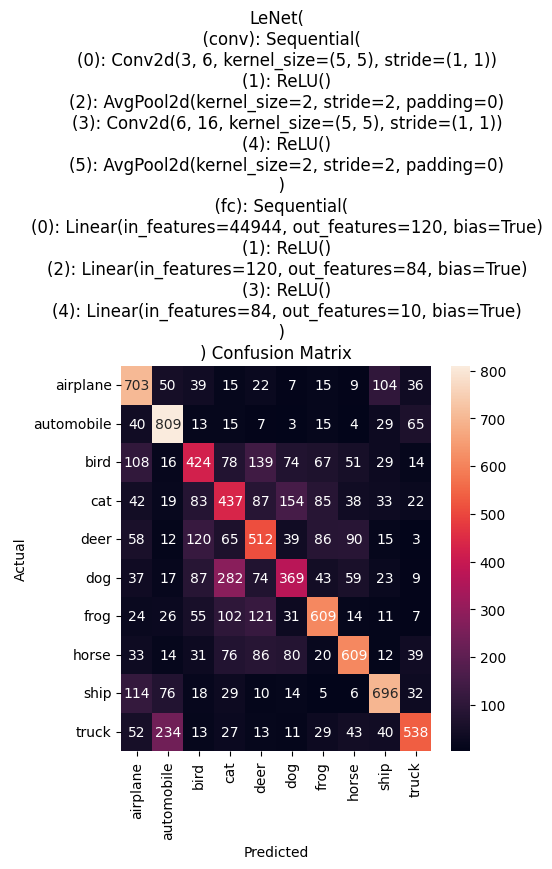

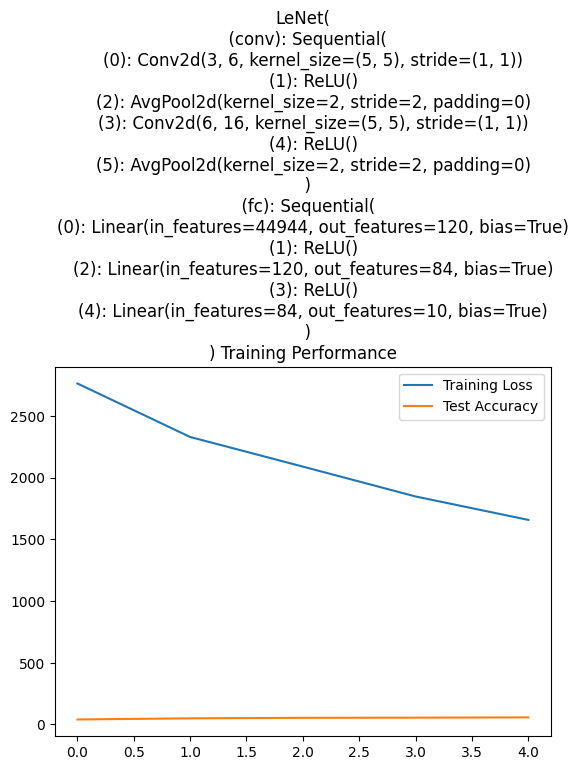

LeNet(
  (conv): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (fc): Sequential(
    (0): Linear(in_features=44944, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): ReLU()
    (4): Linear(in_features=84, out_features=10, bias=True)
  )
) Classification Report:
              precision    recall  f1-score   support

    airplane       0.58      0.70      0.64      1000
  automobile       0.64      0.81      0.71      1000
        bird       0.48      0.42      0.45      1000
         cat       0.39      0.44      0.41      1000
        deer       0.48      0.51      0.49      1000
         dog       0.47      0.37      0.41      1000
        frog       0.63      0.61      0.62      1000
       hors

In [35]:
model=get_model('lenet')
train_loss, test_acc, all_labels, all_preds = train_model(model)
metrics(model, train_loss, test_acc, all_preds, all_labels)

Epoch 1, Loss: 1184.0087, Accuracy=79.6600%
Epoch 2, Loss: 1066.4090, Accuracy=79.9100%
Epoch 3, Loss: 1042.7437, Accuracy=81.1800%
Epoch 4, Loss: 1039.0533, Accuracy=81.2100%
Epoch 5, Loss: 1036.2975, Accuracy=81.4400%


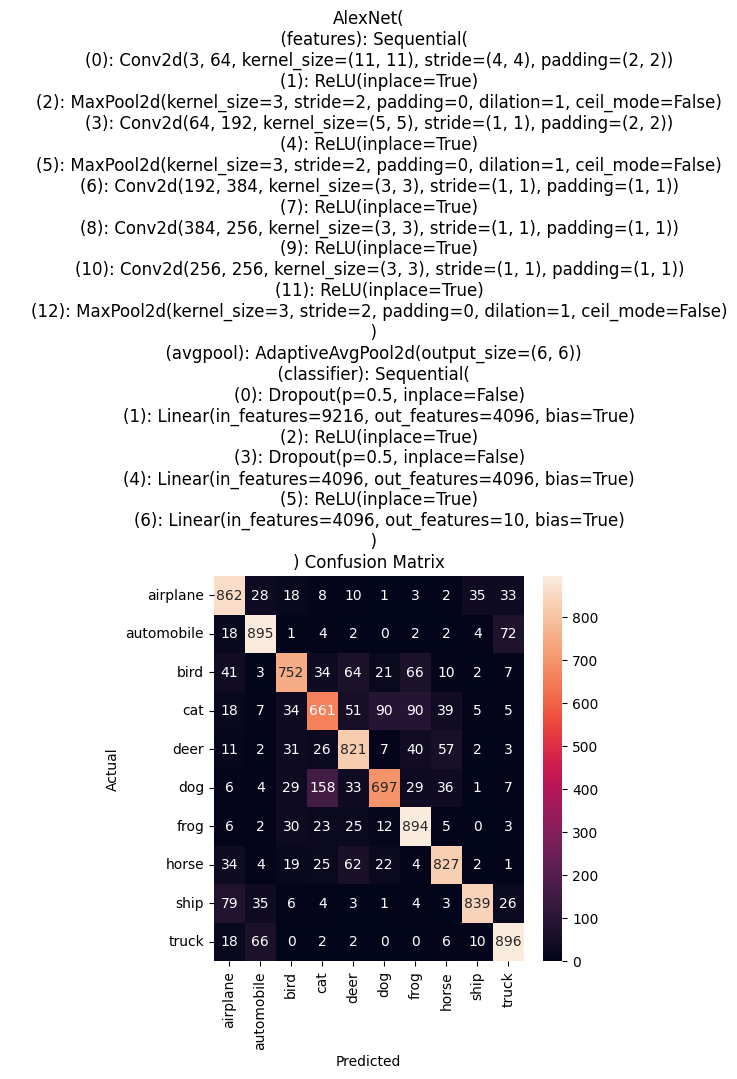

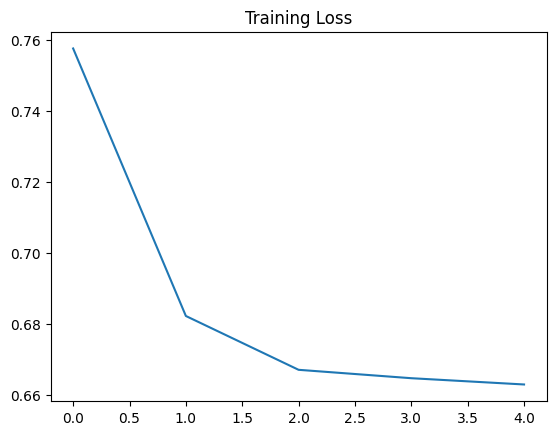

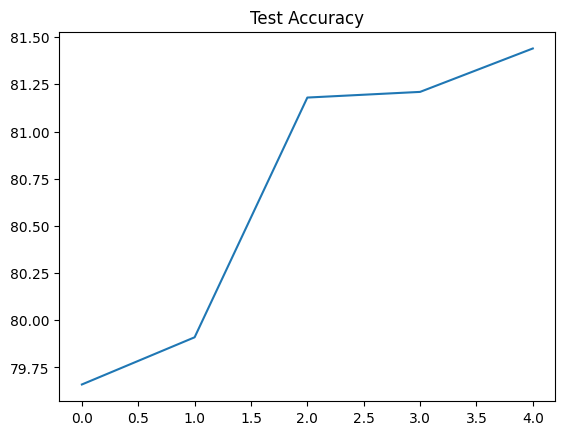

In [9]:
model=get_model('alexnet')
train_loss, test_acc, all_labels, all_preds = train_model(model)
metrics(model, train_loss, test_acc, all_preds, all_labels)

/Users/amishasingh/Documents/DLLab/stable_venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/amishasingh/Documents/DLLab/stable_venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 1056.1340, Accuracy=81.6900%
Epoch 2, Loss: 1009.7343, Accuracy=82.9800%
Epoch 3, Loss: 1017.8691, Accuracy=83.5300%
Epoch 4, Loss: 1023.9511, Accuracy=82.8800%
Epoch 5, Loss: 1041.3362, Accuracy=82.4700%


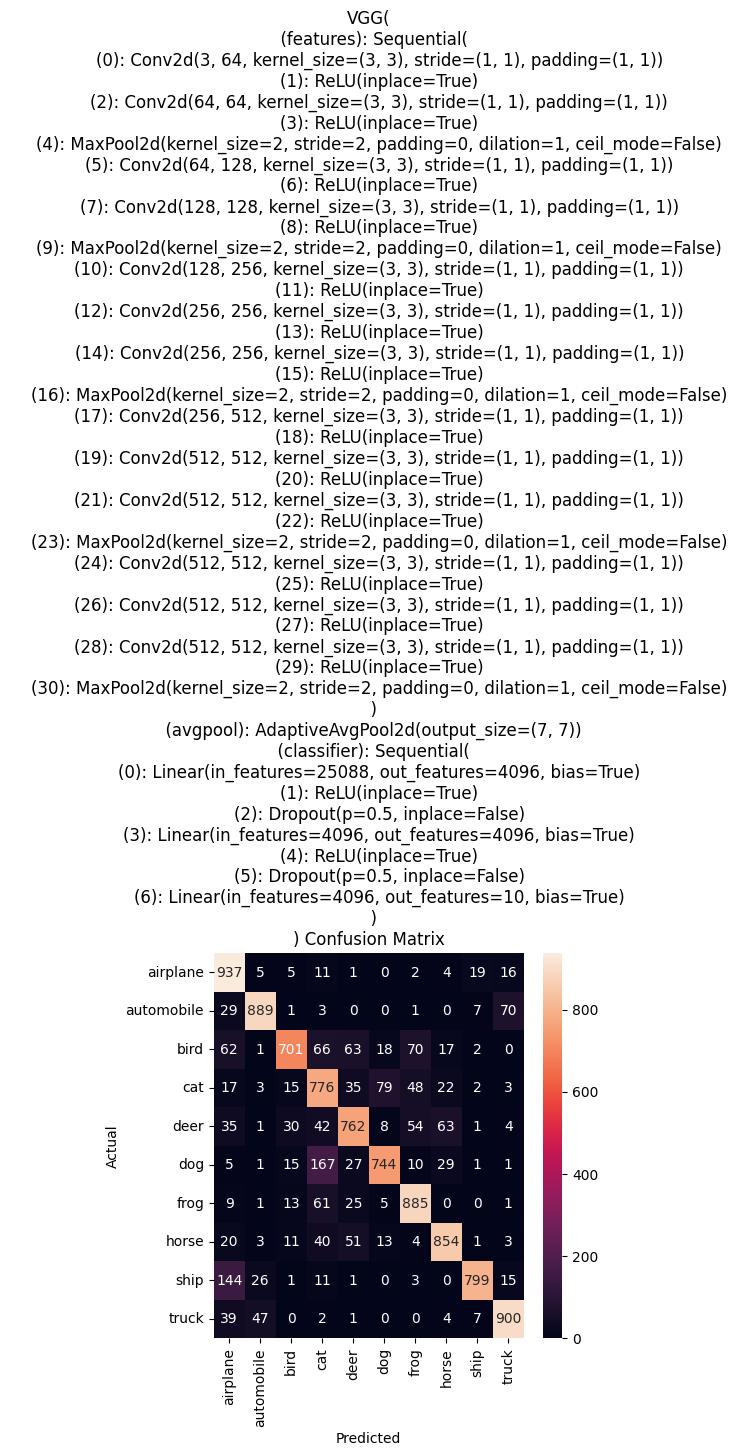

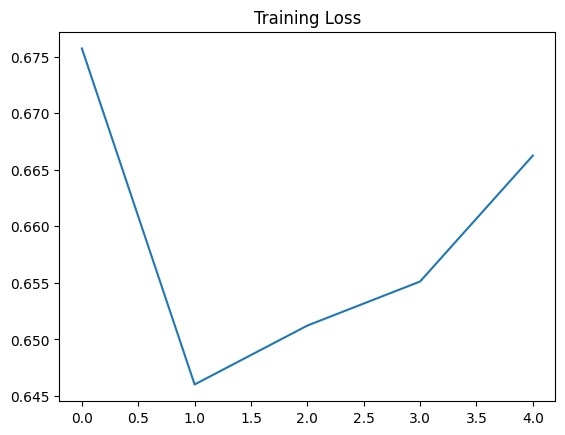

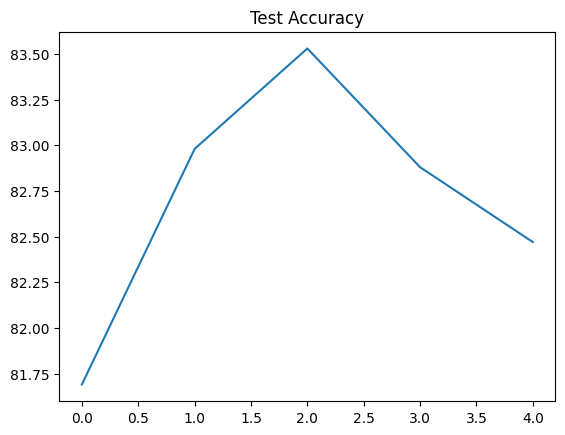

In [12]:
model=get_model('vgg16')
train_loss, test_acc, all_labels, all_preds = train_model(model)
metrics(model, train_loss, test_acc, all_preds, all_labels)

/Users/amishasingh/Documents/DLLab/stable_venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/amishasingh/Documents/DLLab/stable_venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /Users/amishasingh/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100.0%


Epoch 1, Loss: 1032.5947, Accuracy=82.4500%
Epoch 2, Loss: 993.3688, Accuracy=83.3600%
Epoch 3, Loss: 1006.7364, Accuracy=82.8900%
Epoch 4, Loss: 1011.3591, Accuracy=83.8700%
Epoch 5, Loss: 1015.3008, Accuracy=83.2500%


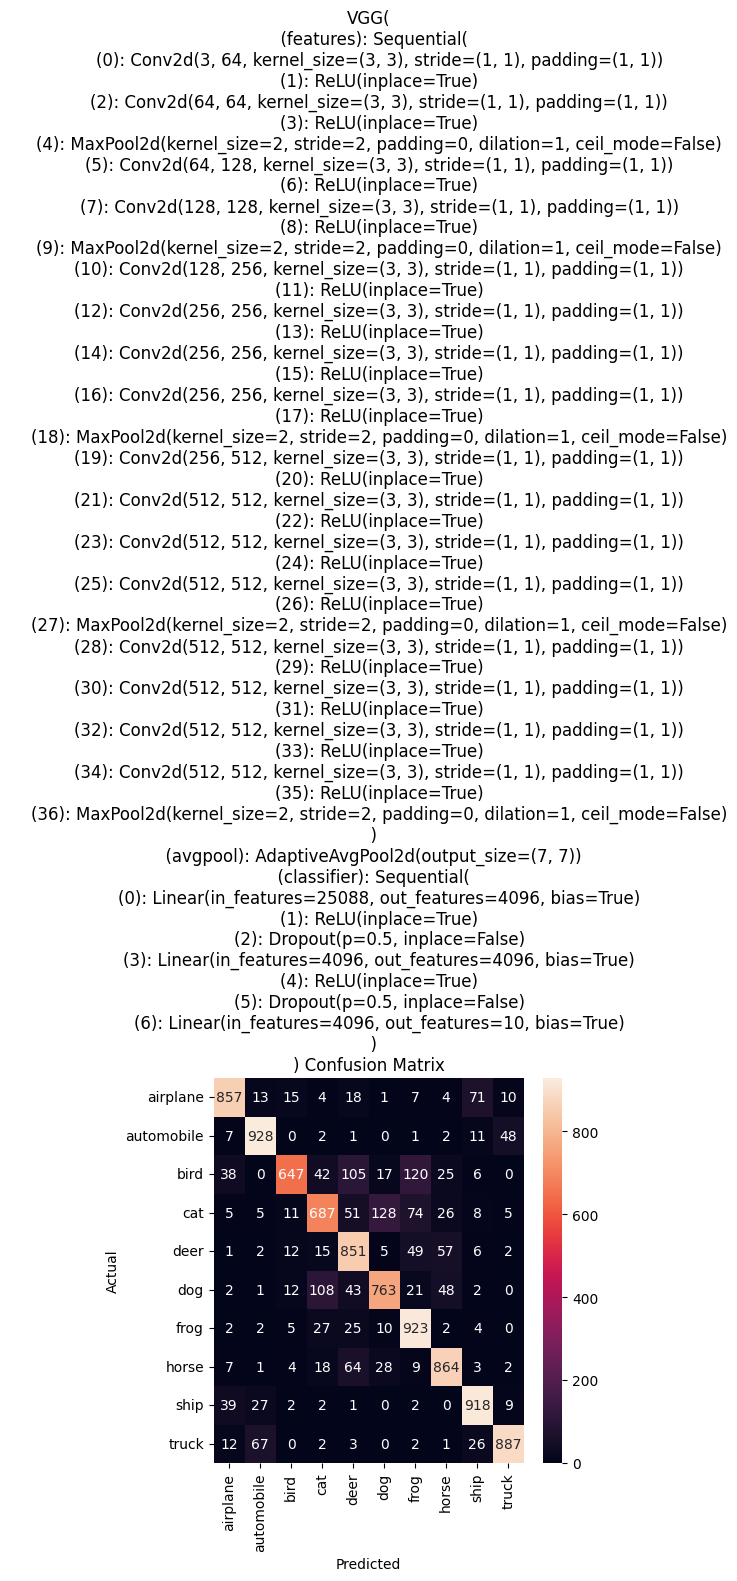

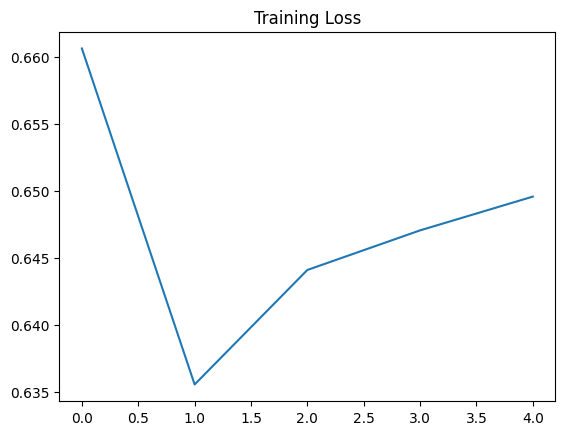

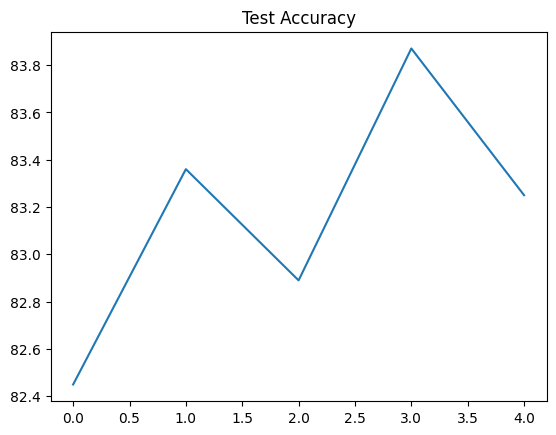

In [8]:
model=get_model('vgg19')
train_loss, test_acc, all_labels, all_preds = train_model(model)
metrics(model, train_loss, test_acc, all_preds, all_labels)

/Users/amishasingh/Documents/DLLab/stable_venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/amishasingh/Documents/DLLab/stable_venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/amishasingh/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Epoch 1, Loss: 1254.9626, Accuracy=77.5400%
Epoch 2, Loss: 998.1108, Accuracy=79.7700%
Epoch 3, Loss: 970.0670, Accuracy=78.8600%
Epoch 4, Loss: 943.8686, Accuracy=80.3900%
Epoch 5, Loss: 935.2428, Accuracy=79.5600%


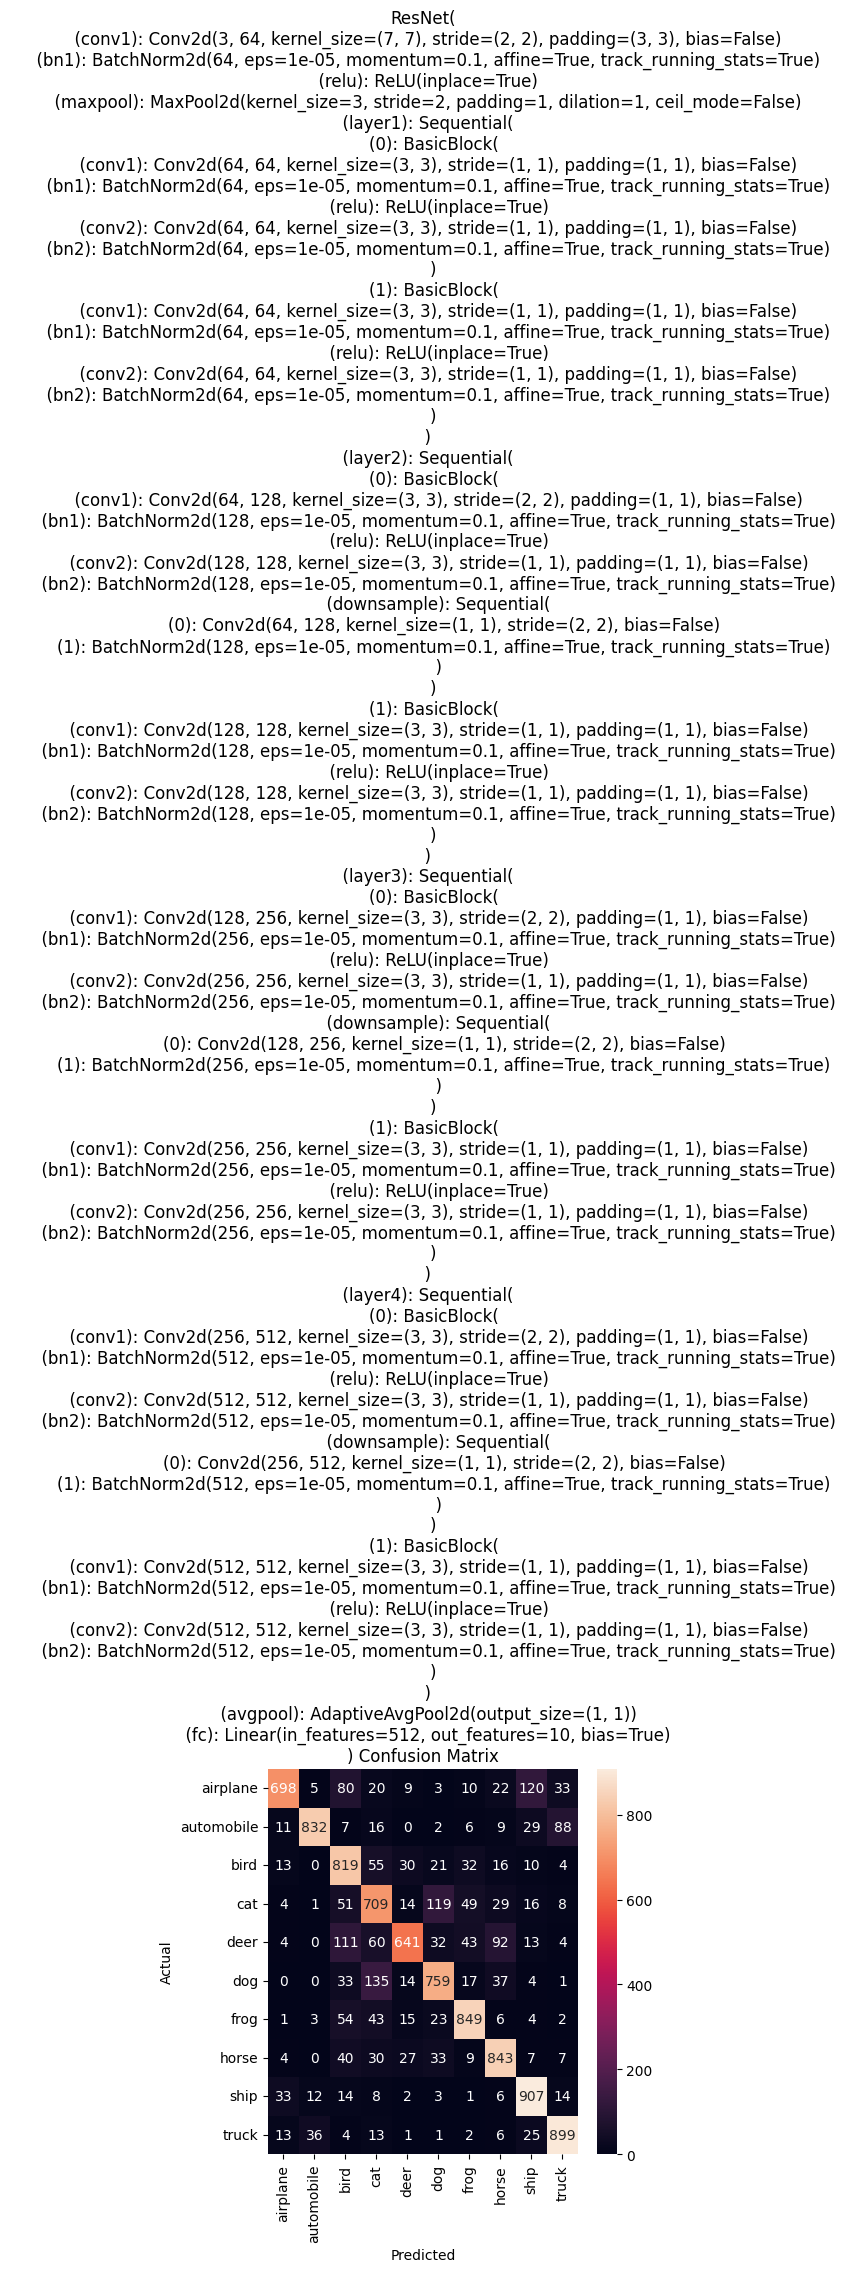

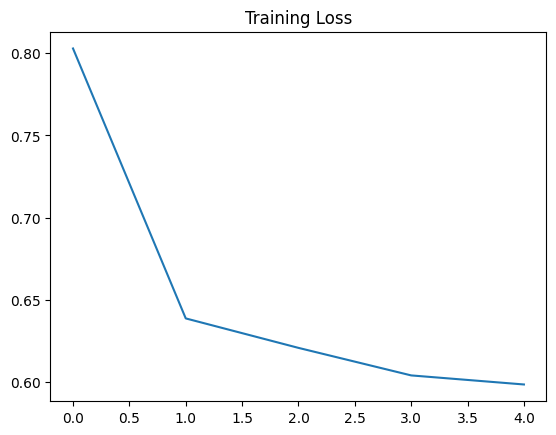

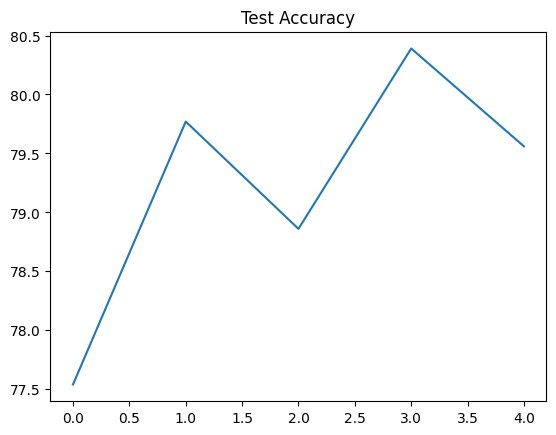

In [13]:
model=get_model('resnet18')
train_loss, test_acc, all_labels, all_preds = train_model(model)
metrics(model, train_loss, test_acc, all_preds, all_labels)

In [ ]:
model=get_model('resnet34')
train_loss, test_acc, all_labels, all_preds = train_model(model)
metrics(model, train_loss, test_acc, all_preds, all_labels)

In [ ]:
self.conv = nn.Sequential(
    nn.Conv2d(3, 6, 5),
    nn.BatchNorm2d(6),
    nn.ReLU(),
    nn.AvgPool2d(2),

    nn.Conv2d(6, 16, 5),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.AvgPool2d(2)
)

self.fc = nn.Sequential(
    nn.Linear(self.flatten_size, 120),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(120, 84),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(84, 10)
)